# Question 2

The PDE is,

$$
\frac{d}{dx}\left(E(x) \frac{du}{dx}\right) = 0
$$

with boundary conditions,

$$
u(x=0) = 0, \quad u(x=L) = u_L
$$

The experimental field is given by,

$$
\hat{u}(x) = \sin(2\pi x) + a_1 \sin(20\pi x) + a_2 \sin(200\pi x) + \text{noise}
$$

Three cases are considered:
* $a_1 = 0.1, a_2 = 10$
* $a_1 = 10, a_2 = 0.1$
* $a_1 = 1, a_2 = 1$

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


u_exact sanity: [0.     0.3499 0.6225 0.8347 1.    ]
E*du/dx (constant): [1.582 1.582 1.582 1.582 1.582]


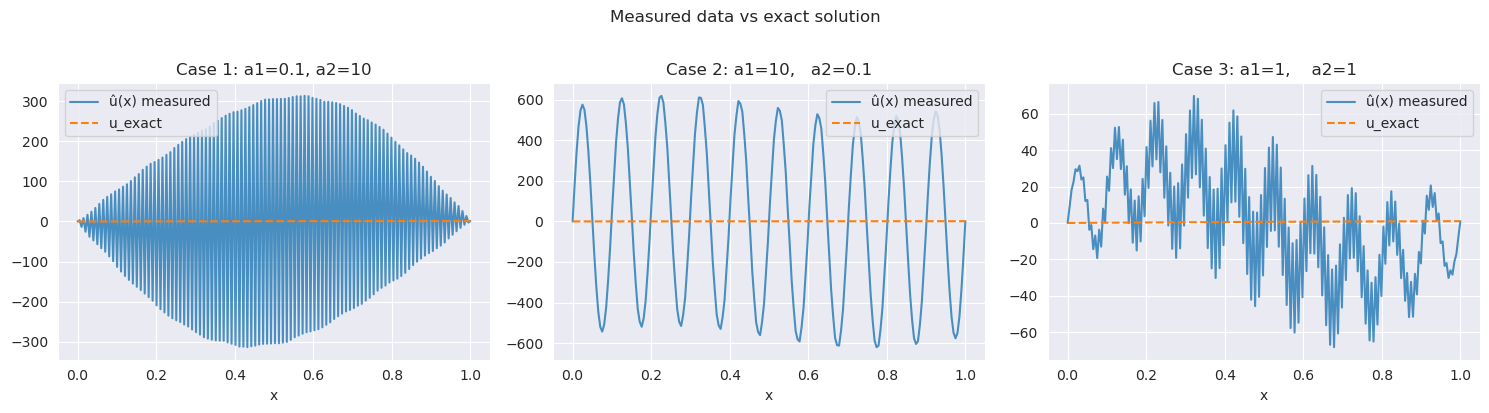

In [3]:
L    = 1.0
u_L  = 1.0
N_data = 200
N_pde  = 1000

def E_true(x_np):
    return np.exp(x_np)

def u_exact(x_np, L=L, uL=u_L):
    C = uL / (1.0 - np.exp(-L))
    return C * (1.0 - np.exp(-x_np))

def dudx_exact(x_np, L=L, uL=u_L):
    C = uL / (1.0 - np.exp(-L))
    return C * np.exp(-x_np)

x_test = np.linspace(0, L, 5)
print("u_exact sanity:", u_exact(x_test).round(4))
print("E*du/dx (constant):", (E_true(x_test)*dudx_exact(x_test)).round(4))

def generate_data(a1, a2, noise_std=0.02, L=L, uL=u_L, N=N_data):
    x      = np.linspace(0, L, N)
    signal = (np.sin(2*np.pi*x/L)
              + a1*np.sin(20*np.pi*x/L)
              + a2*np.sin(200*np.pi*x/L))
    noise  = noise_std * np.random.randn(N)
    u_hat  = signal + noise
    u_hat -= u_hat[0]
    if abs(u_hat[-1]) > 1e-10:
        u_hat *= uL / u_hat[-1]
    else:
        u_hat += uL
    return x, u_hat

cases = [
    (0.1, 10,  "Case 1: a1=0.1, a2=10"),
    (10,  0.1, "Case 2: a1=10,   a2=0.1"),
    (1,   1,   "Case 3: a1=1,    a2=1"),
]

with sns.axes_style("darkgrid"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (a1, a2, title) in zip(axes, cases):
        x, u_hat = generate_data(a1, a2)
        ax.plot(x, u_hat,        label='û(x) measured', alpha=0.8)
        ax.plot(x, u_exact(x), '--', label='u_exact')
        ax.set_title(title); ax.legend(); ax.set_xlabel('x')
    plt.suptitle("Measured data vs exact solution", y=1.02)
    plt.tight_layout(); plt.show()

In [11]:
class FourierFeatureNet(nn.Module):
    def __init__(self, n_fourier=64, hidden=128, n_layers=5, freq_scale=10.0):
        super().__init__()
        B = torch.randn(n_fourier) * freq_scale
        self.register_buffer('B', B)
        in_dim = 2 * n_fourier
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def fourier_embed(self, x):
        proj = x * self.B.unsqueeze(0)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, x):
        return self.net(self.fourier_embed(x))


def get_derivatives(net_u, x):
    x_g = x.detach().clone().requires_grad_(True)
    u   = net_u(x_g)
    du  = torch.autograd.grad(
        u, x_g, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True)[0]
    d2u = torch.autograd.grad(
        du, x_g, grad_outputs=torch.ones_like(du),
        create_graph=True, retain_graph=True)[0]
    return x_g, u, du, d2u


def recover_E(net_u, x, L=1.0):
    x_g = x.detach().clone().requires_grad_(True)
    u   = net_u(x_g)
    du  = torch.autograd.grad(
        u, x_g, grad_outputs=torch.ones_like(u),
        create_graph=False, retain_graph=False)[0]
    du_np = du.detach().cpu().numpy().flatten()

    x0       = torch.zeros(1, 1, device=device)
    x0_g     = x0.requires_grad_(True)
    u0       = net_u(x0_g)
    du0      = torch.autograd.grad(u0, x0_g,
                grad_outputs=torch.ones_like(u0),
                create_graph=False)[0]
    C_flux   = du0.item()

    eps      = 1e-6
    du_safe  = np.where(np.abs(du_np) < eps,
                        np.sign(du_np + 1e-15)*eps, du_np)
    E_pred   = C_flux / du_safe
    if np.mean(E_pred) < 0:
        E_pred = -E_pred
    return E_pred

def compute_loss(net_u, x_data, u_data, x_col, lambda_bc=500.0, lambda_pde=1.0, L=1.0, uL=1.0):

    u_pred    = net_u(x_data)
    loss_data = torch.mean((u_pred - u_data)**2)

    x0      = torch.zeros(1, 1, device=device)
    xL_t    = torch.full((1, 1), L, device=device)
    loss_bc = net_u(x0)**2 + (net_u(xL_t) - uL)**2

    x_g = x_col.detach().clone().requires_grad_(True)
    u_c = net_u(x_g)
    du_c = torch.autograd.grad(
        u_c, x_g, grad_outputs=torch.ones_like(u_c),
        create_graph=True, retain_graph=True)[0]
    flux_proxy = du_c * torch.exp(x_g)
    d_flux     = torch.autograd.grad(
        flux_proxy, x_g, grad_outputs=torch.ones_like(flux_proxy),
        create_graph=True, retain_graph=True)[0]
    loss_pde   = torch.mean(d_flux**2)

    total = loss_data + lambda_bc*loss_bc.squeeze() + lambda_pde*loss_pde
    return total, loss_data.item(), loss_pde.item(), loss_bc.item()

def compute_ntk_weights(net_u, x_data, u_data, x_col, L=1.0, uL=1.0):
    params = list(net_u.parameters())

    u_pred = net_u(x_data)
    l_data = torch.mean((u_pred - u_data)**2)
    g_data = torch.autograd.grad(l_data, params,
                                  retain_graph=True, allow_unused=True)
    norm_data = sum(g.norm()**2 for g in g_data
                    if g is not None).sqrt().item()

    x_g   = x_col.detach().clone().requires_grad_(True)
    u_c   = net_u(x_g)
    du_c  = torch.autograd.grad(
        u_c, x_g, grad_outputs=torch.ones_like(u_c),
        create_graph=True, retain_graph=True)[0]
    flux  = du_c * torch.exp(x_g)
    d_flux= torch.autograd.grad(
        flux, x_g, grad_outputs=torch.ones_like(flux),
        create_graph=True, retain_graph=True)[0]
    l_pde = torch.mean(d_flux**2)
    g_pde = torch.autograd.grad(l_pde, params,
                                 retain_graph=False, allow_unused=True)
    norm_pde = sum(g.norm()**2 for g in g_pde
                   if g is not None).sqrt().item()

    lam = norm_data / (norm_pde + 1e-8)
    return float(np.clip(lam, 0.001, 500.0))

def train_pinn(x_data_np, u_data_np,
               method='wang',
               batch_mode='full',
               n_epochs=8000,
               lr=1e-3,
               L=1.0, uL=1.0,
               freq_scale=10.0,
               print_every=4000):

    net_u  = FourierFeatureNet(n_fourier=64, hidden=128, n_layers=5, freq_scale=freq_scale).to(device)
    x_data = torch.tensor(x_data_np, dtype=torch.float32).unsqueeze(1).to(device)
    u_data = torch.tensor(u_data_np, dtype=torch.float32).unsqueeze(1).to(device)
    x_col  = torch.linspace(0, L, N_pde, device=device).unsqueeze(1)

    opt       = Adam(net_u.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[3000, 6000], gamma=0.3)

    mu         = 1.0
    lam_al     = 0.0
    lambda_pde = 1.0      # starting PDE weight

    history    = {'total': [], 'data': [], 'pde': [], 'bc': []}
    batch_size = 64

    for epoch in range(1, n_epochs + 1):

        if batch_mode == 'mini':
            idx    = torch.randperm(len(x_data))[:batch_size]
            xb     = x_data[idx]; ub = u_data[idx]
            xb_col = x_col[torch.randperm(N_pde)[:batch_size]]
        else:
            xb = x_data; ub = u_data; xb_col = x_col

        # Wang: rebalance every 200 epochs
        if method == 'wang' and epoch % 200 == 0:
            lambda_pde = compute_ntk_weights(net_u, xb, ub, xb_col, L, uL)

        opt.zero_grad()

        if method in ('wang', 'capu'):
            loss, ld, lp, lb = compute_loss(
                net_u, xb, ub, xb_col,
                lambda_bc=500.0, lambda_pde=lambda_pde, L=L, uL=uL)

        elif method == 'auglag':
            x_g   = xb_col.detach().clone().requires_grad_(True)
            u_c   = net_u(x_g)
            du_c  = torch.autograd.grad(u_c, x_g, grad_outputs=torch.ones_like(u_c),create_graph=True, retain_graph=True)[0]
            flux  = du_c * torch.exp(x_g)
            d_flux= torch.autograd.grad(flux, x_g, grad_outputs=torch.ones_like(flux),create_graph=True, retain_graph=True)[0]
            pde_mean  = torch.mean(d_flux**2)

            u_pred    = net_u(xb)
            loss_data = torch.mean((u_pred - ub)**2)

            x0      = torch.zeros(1, 1, device=device)
            xLt     = torch.full((1, 1), L, device=device)
            bc_viol = net_u(x0)**2 + (net_u(xLt) - uL)**2

            loss = (loss_data
                    + lam_al * pde_mean
                    + (mu/2.0) * pde_mean**2
                    + 500.0 * bc_viol.squeeze())
            ld, lp, lb = loss_data.item(), pde_mean.item(), bc_viol.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(net_u.parameters(), 1.0)
        opt.step()
        scheduler.step()

        # Augmented Lagrangian multiplier update
        if method == 'auglag' and epoch % 100 == 0:
            x_g2  = x_col.detach().clone().requires_grad_(True)
            u_c2  = net_u(x_g2)
            du_c2 = torch.autograd.grad(
                u_c2, x_g2, grad_outputs=torch.ones_like(u_c2),create_graph=True, retain_graph=True)[0]
            fl2   = du_c2 * torch.exp(x_g2)
            dfl2  = torch.autograd.grad(fl2, x_g2, grad_outputs=torch.ones_like(fl2),create_graph=False, retain_graph=False)[0]
            pde_val = torch.mean(dfl2**2).item()
            lam_al  = lam_al + mu * pde_val
            mu      = min(mu * 1.05, 1e3)

        # CAPU multiplier update
        if method == 'capu' and epoch % 100 == 0:
            x_g2  = x_col.detach().clone().requires_grad_(True)
            u_c2  = net_u(x_g2)
            du_c2 = torch.autograd.grad(
                u_c2, x_g2, grad_outputs=torch.ones_like(u_c2),create_graph=True, retain_graph=True)[0]
            fl2   = du_c2 * torch.exp(x_g2)
            dfl2  = torch.autograd.grad(
                fl2, x_g2, grad_outputs=torch.ones_like(fl2),create_graph=False, retain_graph=False)[0]
            pde_val = torch.mean(dfl2**2).item()
            if pde_val > 1e-5:
                lam_al     = lam_al + mu * pde_val
                lambda_pde = lam_al
                mu         = min(mu * 1.05, 1e4)

        history['total'].append(loss.item())
        history['data'].append(ld)
        history['pde'].append(lp)
        history['bc'].append(lb)

        if epoch % print_every == 0:
            print(f"  Epoch {epoch:5d} | Data {ld:.3e} | "
                  f"PDE {lp:.3e} | BC {lb:.3e} | λ {lambda_pde:.4f}")

    return net_u, history

def plot_results(results, method_name, cases, L=1.0):
    with sns.axes_style("darkgrid"):
        fig, axes = plt.subplots(3, 4, figsize=(22, 15))
        x_plot_np = np.linspace(0, L, 500)
        x_plot    = torch.tensor(x_plot_np, dtype=torch.float32).unsqueeze(1).to(device)

        for row, (a1, a2, title) in enumerate(cases):
            for col, bmode in enumerate(['full', 'mini']):
                net_u, _ = results[(a1, a2, bmode)]
                net_u.eval()
                with torch.no_grad():
                    u_pred_np = net_u(x_plot).cpu().numpy().flatten()
                E_pred_np = recover_E(net_u, x_plot, L=L)
                u_ex      = u_exact(x_plot_np, L, u_L)
                E_tr      = E_true(x_plot_np)

                ax = axes[row, col]
                ax.plot(x_plot_np, u_ex,      'k--', lw=2, label='u exact')
                ax.plot(x_plot_np, u_pred_np, 'b-',  lw=1.5, label='u PINN')
                _, u_noisy = generate_data(a1, a2, L=L, uL=u_L)
                ax.scatter(np.linspace(0, L, N_data), u_noisy,
                        s=3, c='gray', alpha=0.3, label='data')
                ax.set_title(f"{title}\n{bmode}-batch | u(x)")
                ax.legend(fontsize=7); ax.set_xlabel('x')

                rmse = np.sqrt(np.mean((E_pred_np - E_tr)**2))
                ax2  = axes[row, col+2]
                ax2.plot(x_plot_np, E_tr,      'k--', lw=2,   label='E true=exp(x)')
                ax2.plot(x_plot_np, E_pred_np, 'r-',  lw=1.5, label='E recovered')
                ax2.set_title(f"{title}\n{bmode}-batch | E(x)  RMSE={rmse:.4f}")
                ax2.legend(fontsize=7); ax2.set_xlabel('x')
                ax2.set_ylim([0, 4])

        plt.suptitle(f"Results: {method_name}", fontsize=14, y=1.01)
        plt.tight_layout(); plt.show()


def plot_convergence(results, method_name, cases):
    with sns.axes_style("darkgrid"):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for ax, (a1, a2, title) in zip(axes, cases):
            for bmode, ls in [('full', '-'), ('mini', '--')]:
                hist = results[(a1, a2, bmode)][1]
                ax.semilogy(hist['total'], ls=ls,          label=f'{bmode} total')
                ax.semilogy(hist['pde'],   ls=ls, alpha=0.5, label=f'{bmode} PDE')
            ax.set_title(title)
            ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        plt.suptitle(f"Convergence: {method_name}", fontsize=13)
        plt.tight_layout(); plt.show()


def compare_methods(cases, rw, ra, rc, L=1.0):
    with sns.axes_style("darkgrid"):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        x_plot_np = np.linspace(0, L, 500)
        x_plot    = torch.tensor(x_plot_np, dtype=torch.float32
                                ).unsqueeze(1).to(device)
        E_tr      = E_true(x_plot_np)
        for ax, (a1, a2, title) in zip(axes, cases):
            ax.plot(x_plot_np, E_tr, 'k--', lw=2, label='E true')
            for rdict, mname, col in [(rw, 'Wang',   'blue'),
                                    (ra, 'AugLag', 'red'),
                                    (rc, 'CAPU',   'green')]:
                net_u, _ = rdict[(a1, a2, 'full')]
                net_u.eval()
                E_pred = recover_E(net_u, x_plot, L=L)
                ax.plot(x_plot_np, E_pred, color=col, lw=1.5, label=mname)
            ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('E(x)')
            ax.set_ylim([0, 4]); ax.legend(); ax.grid(True, alpha=0.3)
        plt.suptitle("E(x) Recovery — All Methods (full-batch)", fontsize=13)
        plt.tight_layout(); plt.show()


  PART (i): Wang et al. gradient balancing

  Case 1: a1=0.1, a2=10
    batch=full
  Epoch  4000 | Data 2.374e+05 | PDE 1.511e-02 | BC 1.033e-03 | λ 19.9091
  Epoch  8000 | Data 2.374e+05 | PDE 5.010e-04 | BC 9.004e-04 | λ 78.3225
    batch=mini
  Epoch  4000 | Data 2.006e+05 | PDE 5.091e-02 | BC 2.086e-02 | λ 19.8193
  Epoch  8000 | Data 2.637e+05 | PDE 1.413e-03 | BC 1.055e-03 | λ 350.1924

  Case 2: a1=10,   a2=0.1
    batch=full
  Epoch  4000 | Data 9.398e+05 | PDE 4.531e-03 | BC 1.395e-02 | λ 155.5471
  Epoch  8000 | Data 9.398e+05 | PDE 5.913e-04 | BC 1.439e-02 | λ 327.5850
    batch=mini
  Epoch  4000 | Data 8.384e+05 | PDE 1.202e-01 | BC 2.692e-02 | λ 118.5262
  Epoch  8000 | Data 9.342e+05 | PDE 1.579e-03 | BC 1.023e-02 | λ 500.0000

  Case 3: a1=1,    a2=1
    batch=full
  Epoch  4000 | Data 3.021e+06 | PDE 1.549e-02 | BC 4.769e-01 | λ 319.9479
  Epoch  8000 | Data 3.021e+06 | PDE 2.308e-03 | BC 4.814e-01 | λ 500.0000
    batch=mini
  Epoch  4000 | Data 2.932e+06 | PDE 7.396

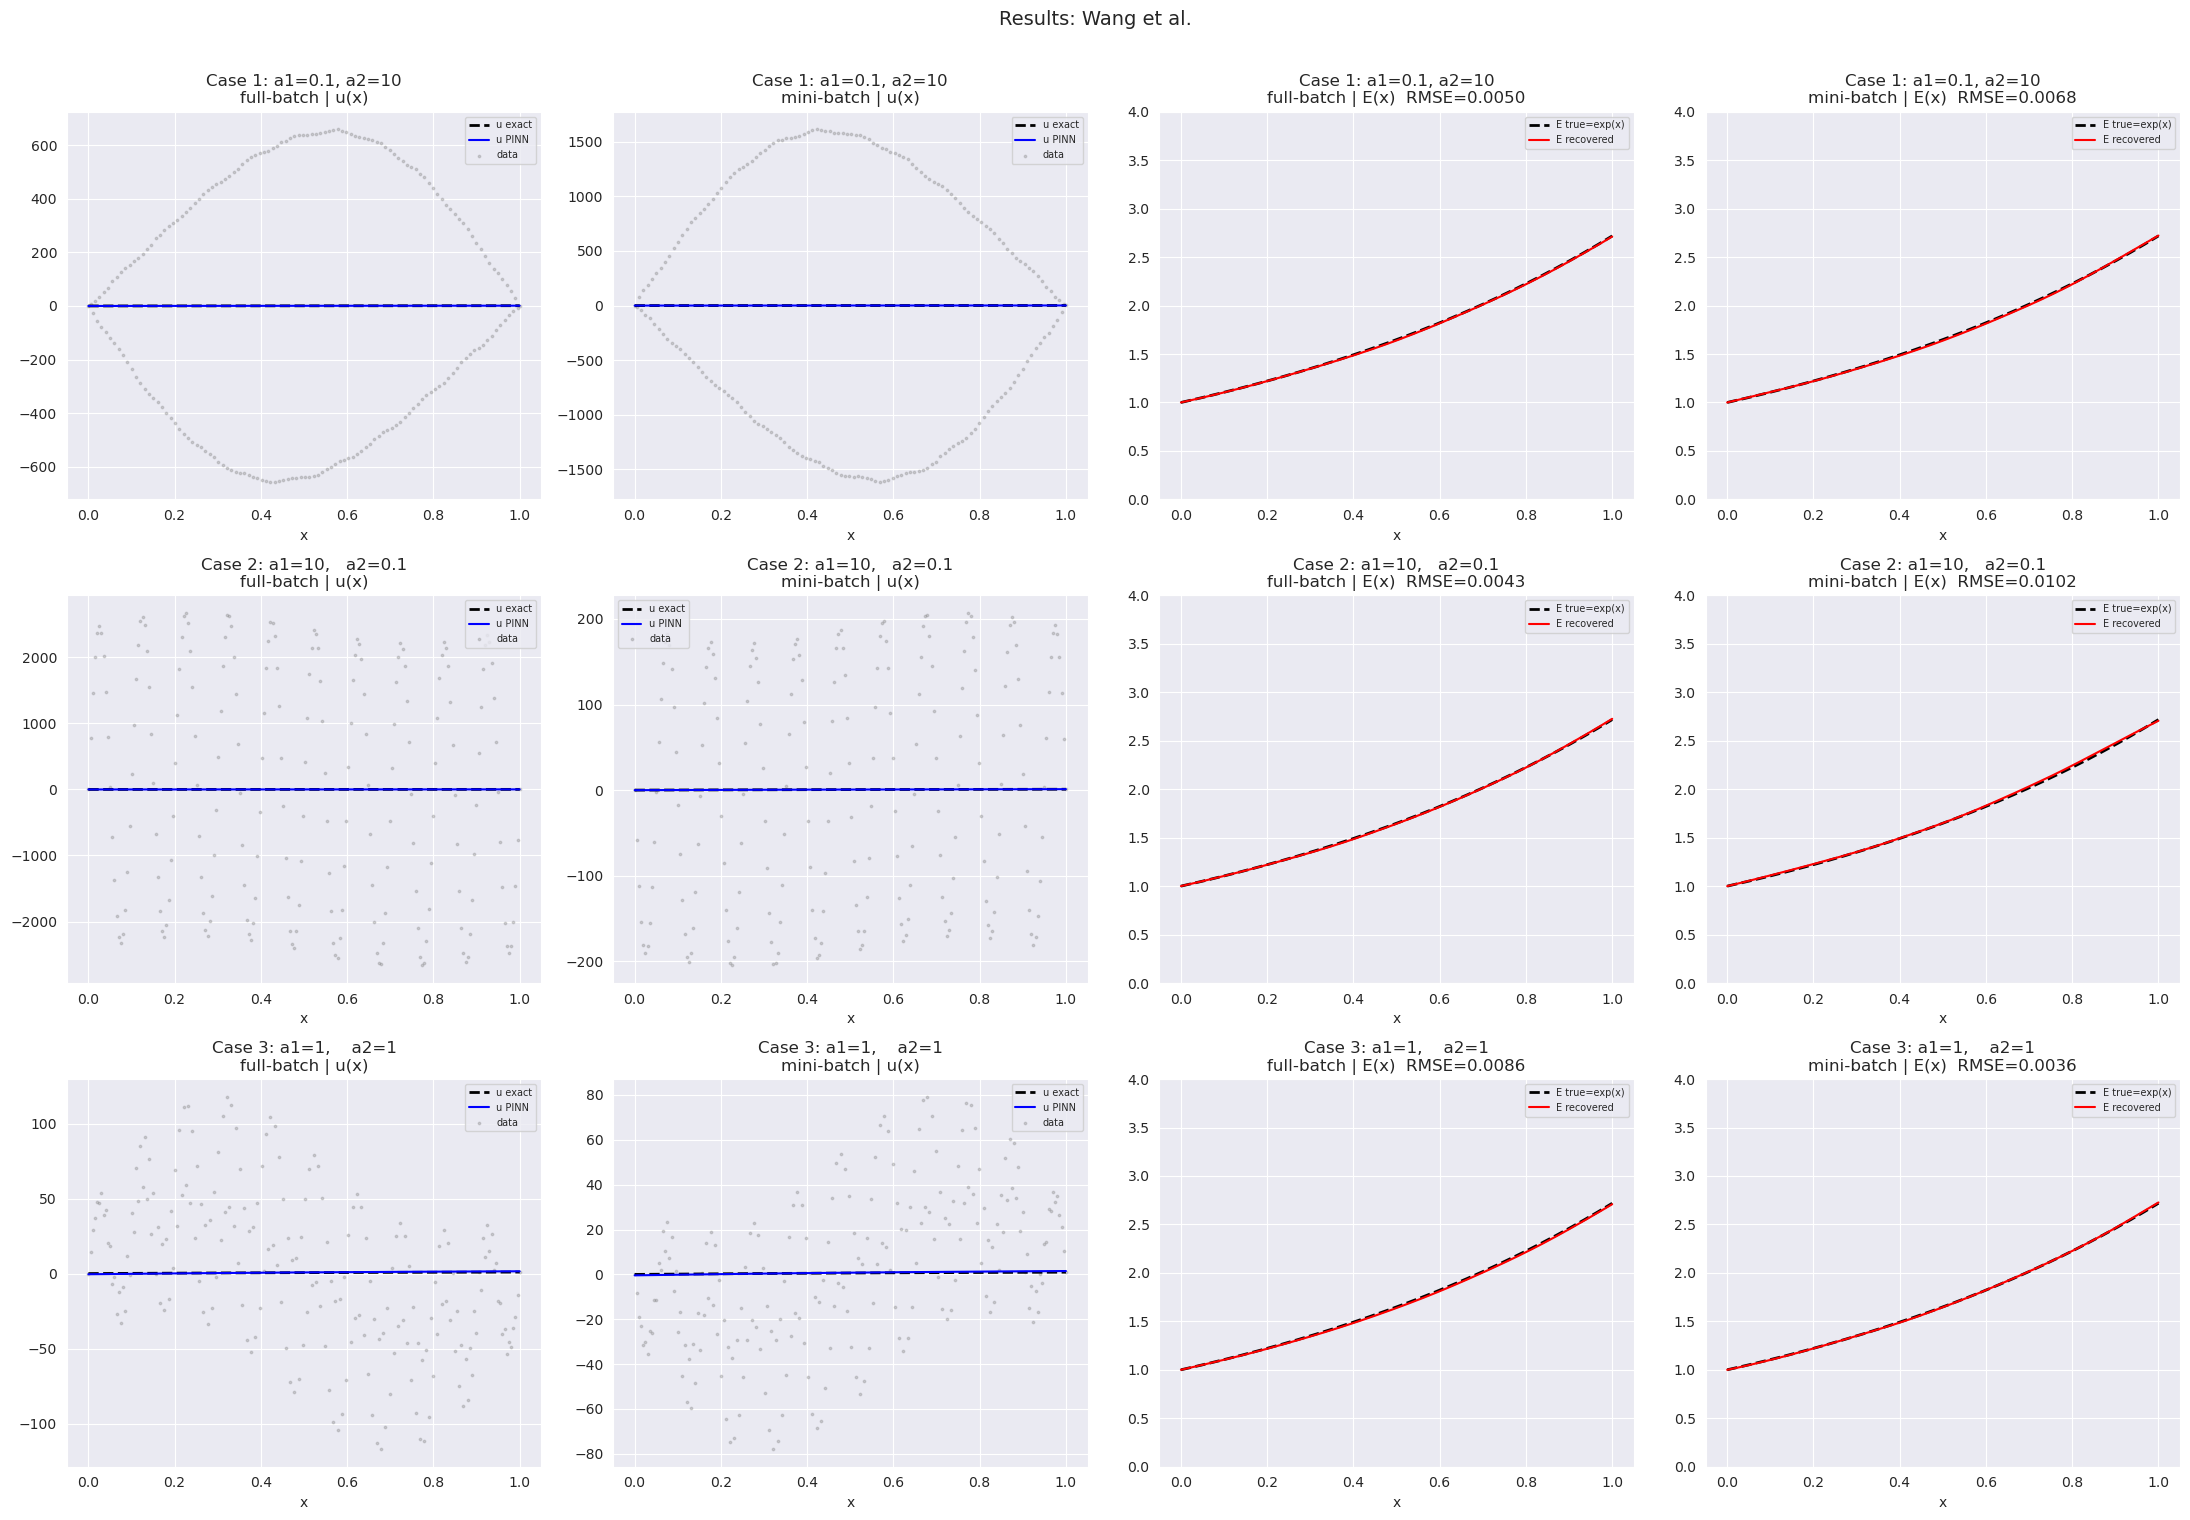

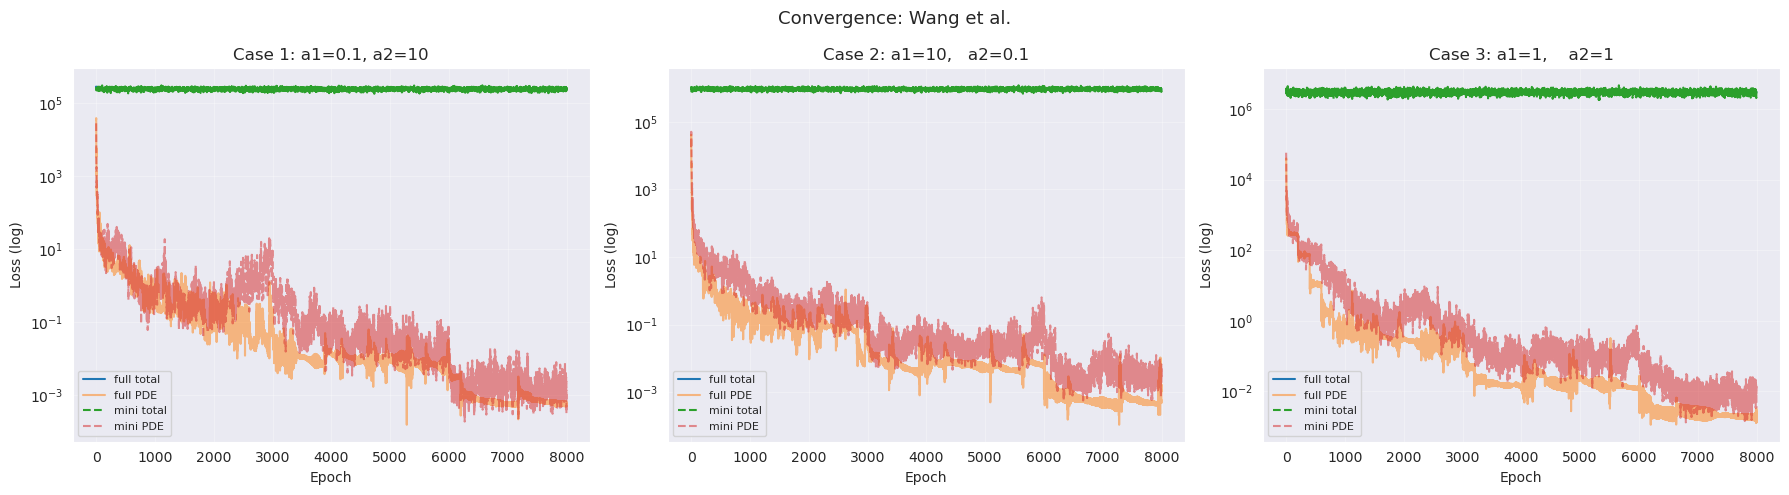

In [5]:
print("\n" + "="*60)
print("  PART (i): Wang et al. gradient balancing")
print("="*60)
results_wang = {}
for a1, a2, title in cases:
    print(f"\n  {title}")
    x_np, u_np = generate_data(a1, a2, L=L, uL=u_L)
    for bmode in ['full', 'mini']:
        print(f"    batch={bmode}")
        net_u, hist = train_pinn(x_np, u_np, method='wang',
                                  batch_mode=bmode, n_epochs=8000,
                                  lr=1e-3, L=L, uL=u_L,
                                  freq_scale=10.0, print_every=4000)
        results_wang[(a1, a2, bmode)] = (net_u, hist)

plot_results(results_wang, "Wang et al.", cases)
plot_convergence(results_wang, "Wang et al.", cases)


  PART (ii): Augmented Lagrangian

  Case 1: a1=0.1, a2=10
    batch=full
  Epoch  4000 | Data 2.378e+06 | PDE 2.970e-02 | BC 8.988e-03 | λ 1.0000
  Epoch  8000 | Data 2.378e+06 | PDE 8.684e-03 | BC 9.239e-03 | λ 1.0000
    batch=mini
  Epoch  4000 | Data 2.613e+06 | PDE 8.135e-02 | BC 7.503e-03 | λ 1.0000
  Epoch  8000 | Data 2.403e+06 | PDE 1.857e-02 | BC 1.801e-02 | λ 1.0000

  Case 2: a1=10,   a2=0.1
    batch=full
  Epoch  4000 | Data 2.650e+04 | PDE 5.013e-04 | BC 4.876e-04 | λ 1.0000
  Epoch  8000 | Data 2.650e+04 | PDE 4.365e-04 | BC 4.247e-04 | λ 1.0000
    batch=mini
  Epoch  4000 | Data 2.602e+04 | PDE 2.180e-02 | BC 4.332e-04 | λ 1.0000
  Epoch  8000 | Data 2.668e+04 | PDE 1.193e-03 | BC 8.343e-04 | λ 1.0000

  Case 3: a1=1,    a2=1
    batch=full
  Epoch  4000 | Data 3.217e+04 | PDE 2.477e-02 | BC 4.865e-03 | λ 1.0000
  Epoch  8000 | Data 3.217e+04 | PDE 5.976e-03 | BC 5.080e-03 | λ 1.0000
    batch=mini
  Epoch  4000 | Data 2.880e+04 | PDE 4.228e-02 | BC 3.697e-03 | λ 1.

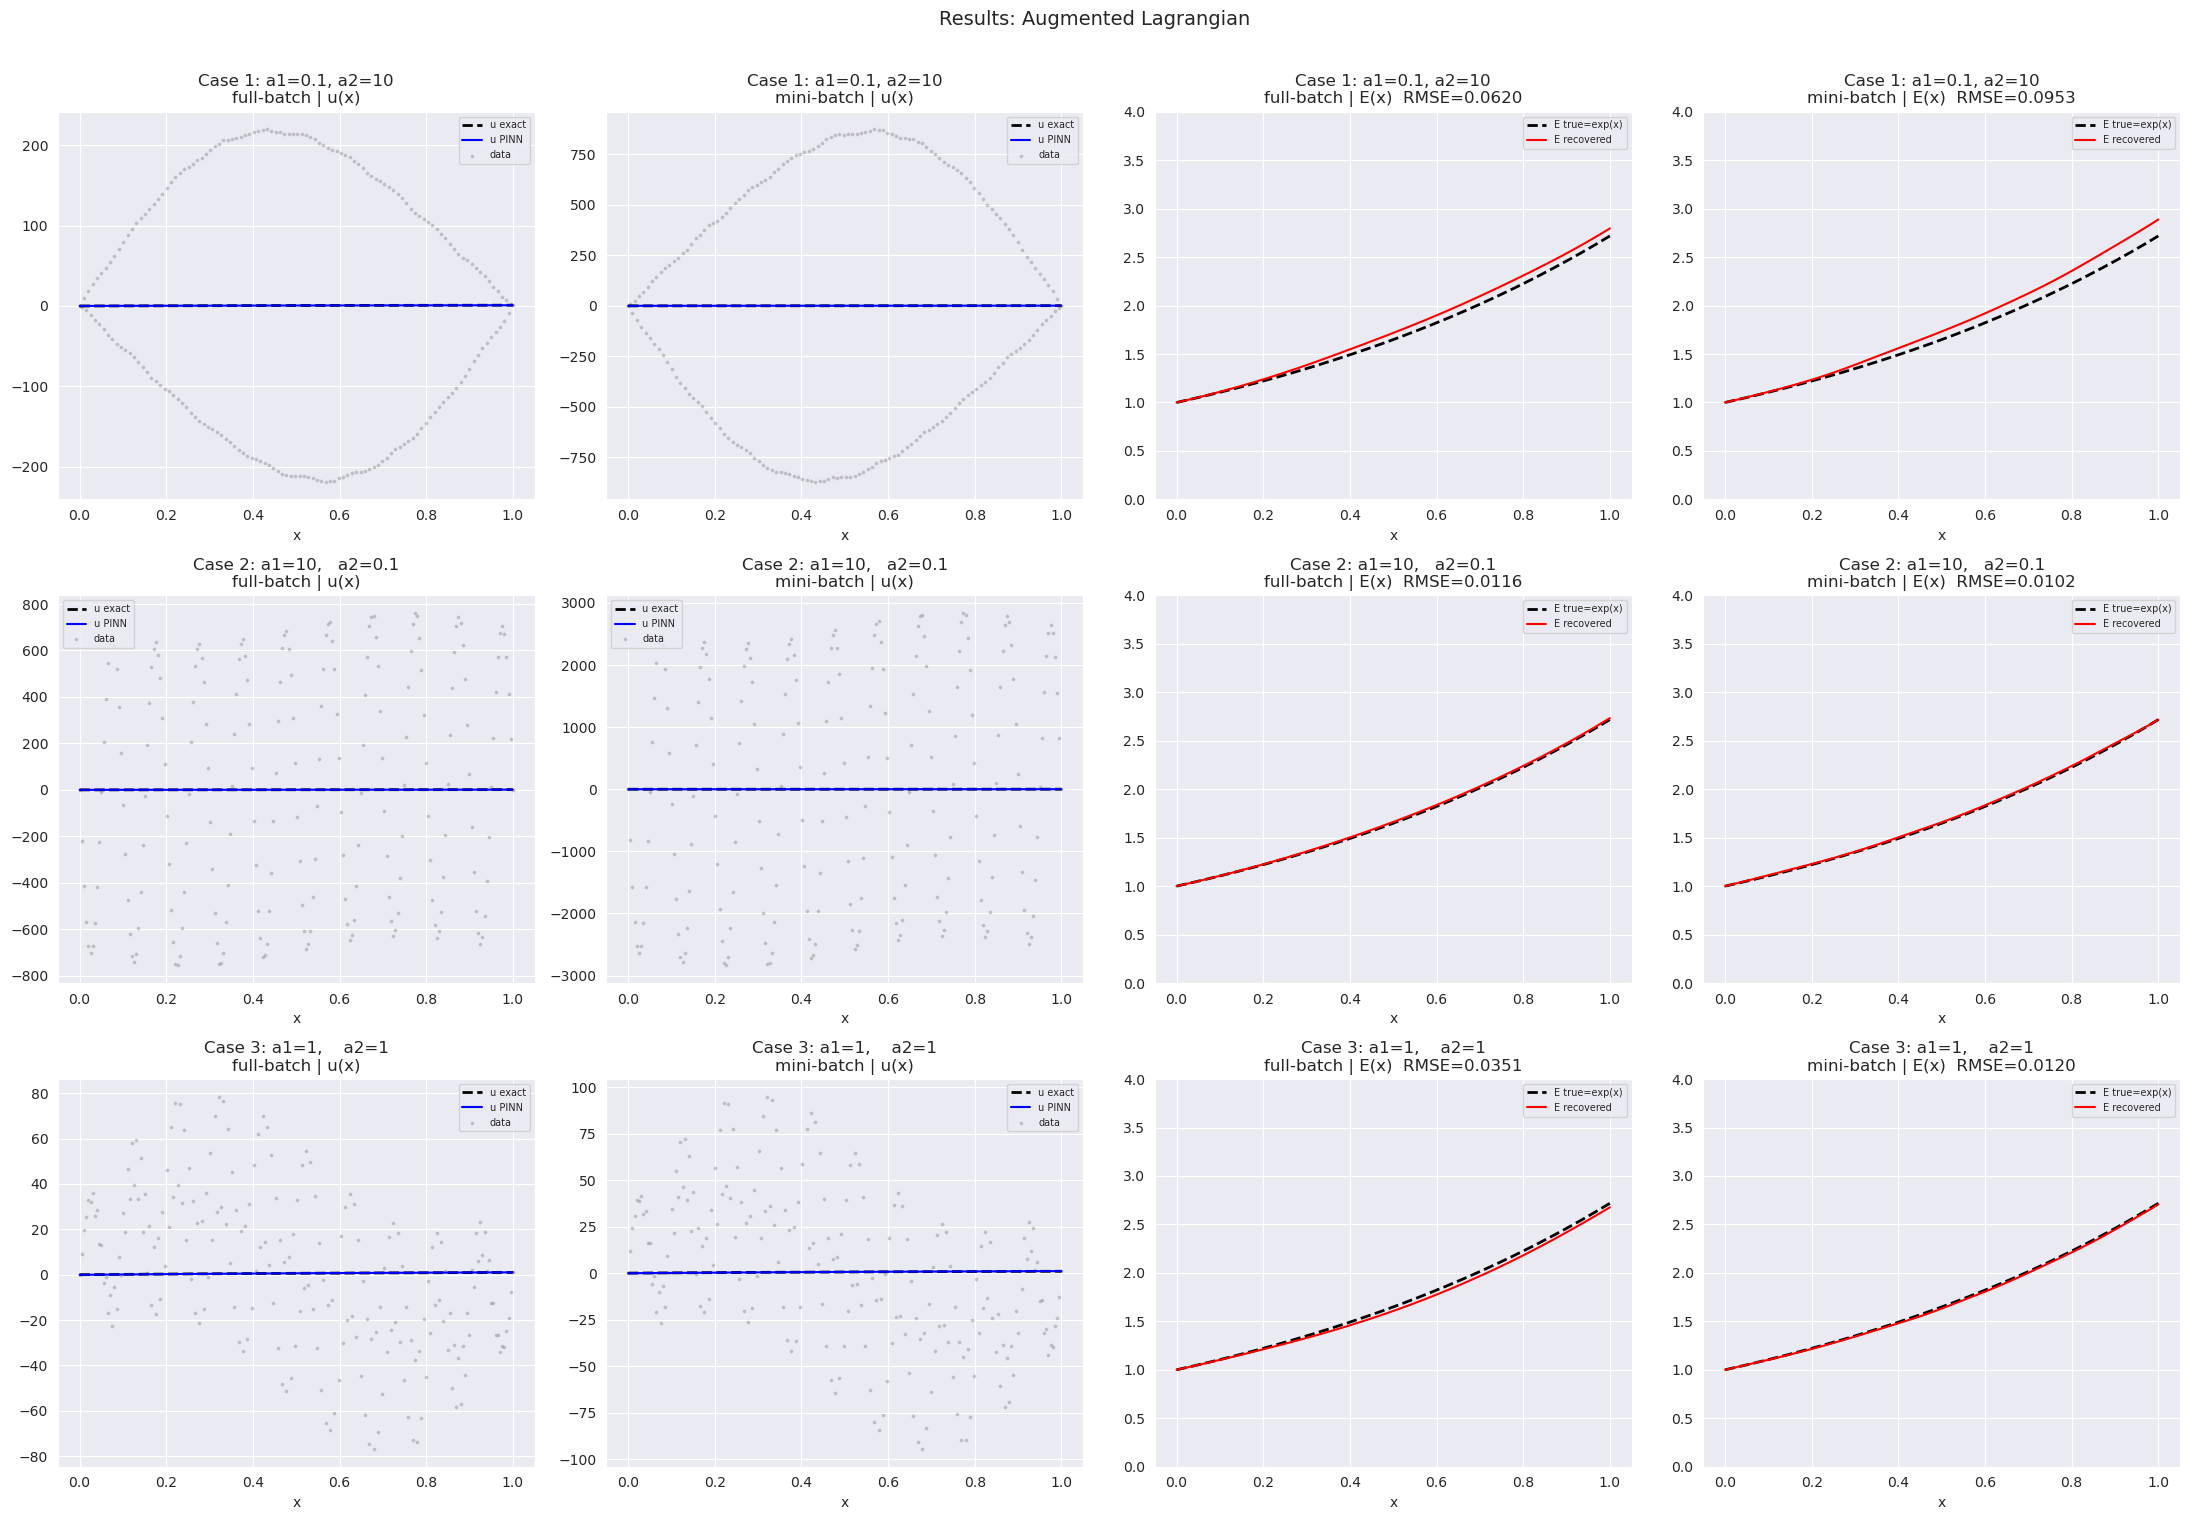

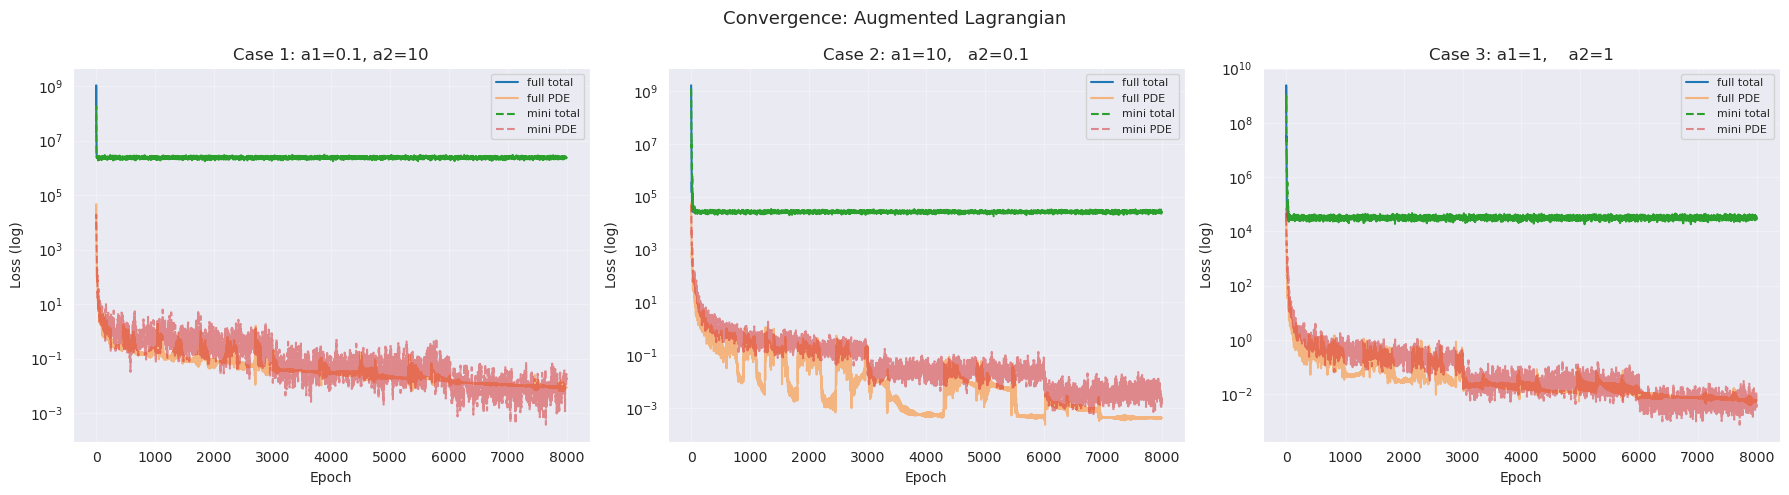

In [6]:
print("\n" + "="*60)
print("  PART (ii): Augmented Lagrangian")
print("="*60)
results_auglag = {}
for a1, a2, title in cases:
    print(f"\n  {title}")
    x_np, u_np = generate_data(a1, a2, L=L, uL=u_L)
    for bmode in ['full', 'mini']:
        print(f"    batch={bmode}")
        net_u, hist = train_pinn(x_np, u_np, method='auglag',
                                  batch_mode=bmode, n_epochs=8000,
                                  lr=1e-3, L=L, uL=u_L,
                                  freq_scale=10.0, print_every=4000)
        results_auglag[(a1, a2, bmode)] = (net_u, hist)

plot_results(results_auglag, "Augmented Lagrangian", cases)
plot_convergence(results_auglag, "Augmented Lagrangian", cases)


  PART (iii): CAPU

  Case 1: a1=0.1, a2=10
    batch=full
  Epoch  4000 | Data 4.326e+04 | PDE 4.557e-03 | BC 3.103e-04 | λ 16.8966
  Epoch  8000 | Data 4.326e+04 | PDE 2.244e-03 | BC 1.812e-04 | λ 19.0810
    batch=mini
  Epoch  4000 | Data 4.637e+04 | PDE 4.926e-02 | BC 2.479e-03 | λ 47.8939
  Epoch  8000 | Data 4.629e+04 | PDE 4.586e-03 | BC 9.613e-04 | λ 57.1596

  Case 2: a1=10,   a2=0.1
    batch=full
  Epoch  4000 | Data 1.483e+04 | PDE 3.277e-02 | BC 2.122e-04 | λ 10.5436
  Epoch  8000 | Data 1.483e+04 | PDE 2.566e-04 | BC 2.398e-04 | λ 12.5467
    batch=mini
  Epoch  4000 | Data 1.453e+04 | PDE 1.691e-02 | BC 1.132e-03 | λ 34.1631
  Epoch  8000 | Data 1.499e+04 | PDE 4.719e-03 | BC 5.054e-04 | λ 42.2913

  Case 3: a1=1,    a2=1
    batch=full
  Epoch  4000 | Data 2.923e+05 | PDE 2.494e-02 | BC 4.575e-02 | λ 37.5155
  Epoch  8000 | Data 2.923e+05 | PDE 1.157e-02 | BC 4.554e-02 | λ 51.4515
    batch=mini
  Epoch  4000 | Data 2.480e+05 | PDE 1.036e-02 | BC 5.140e-02 | λ 84.0056

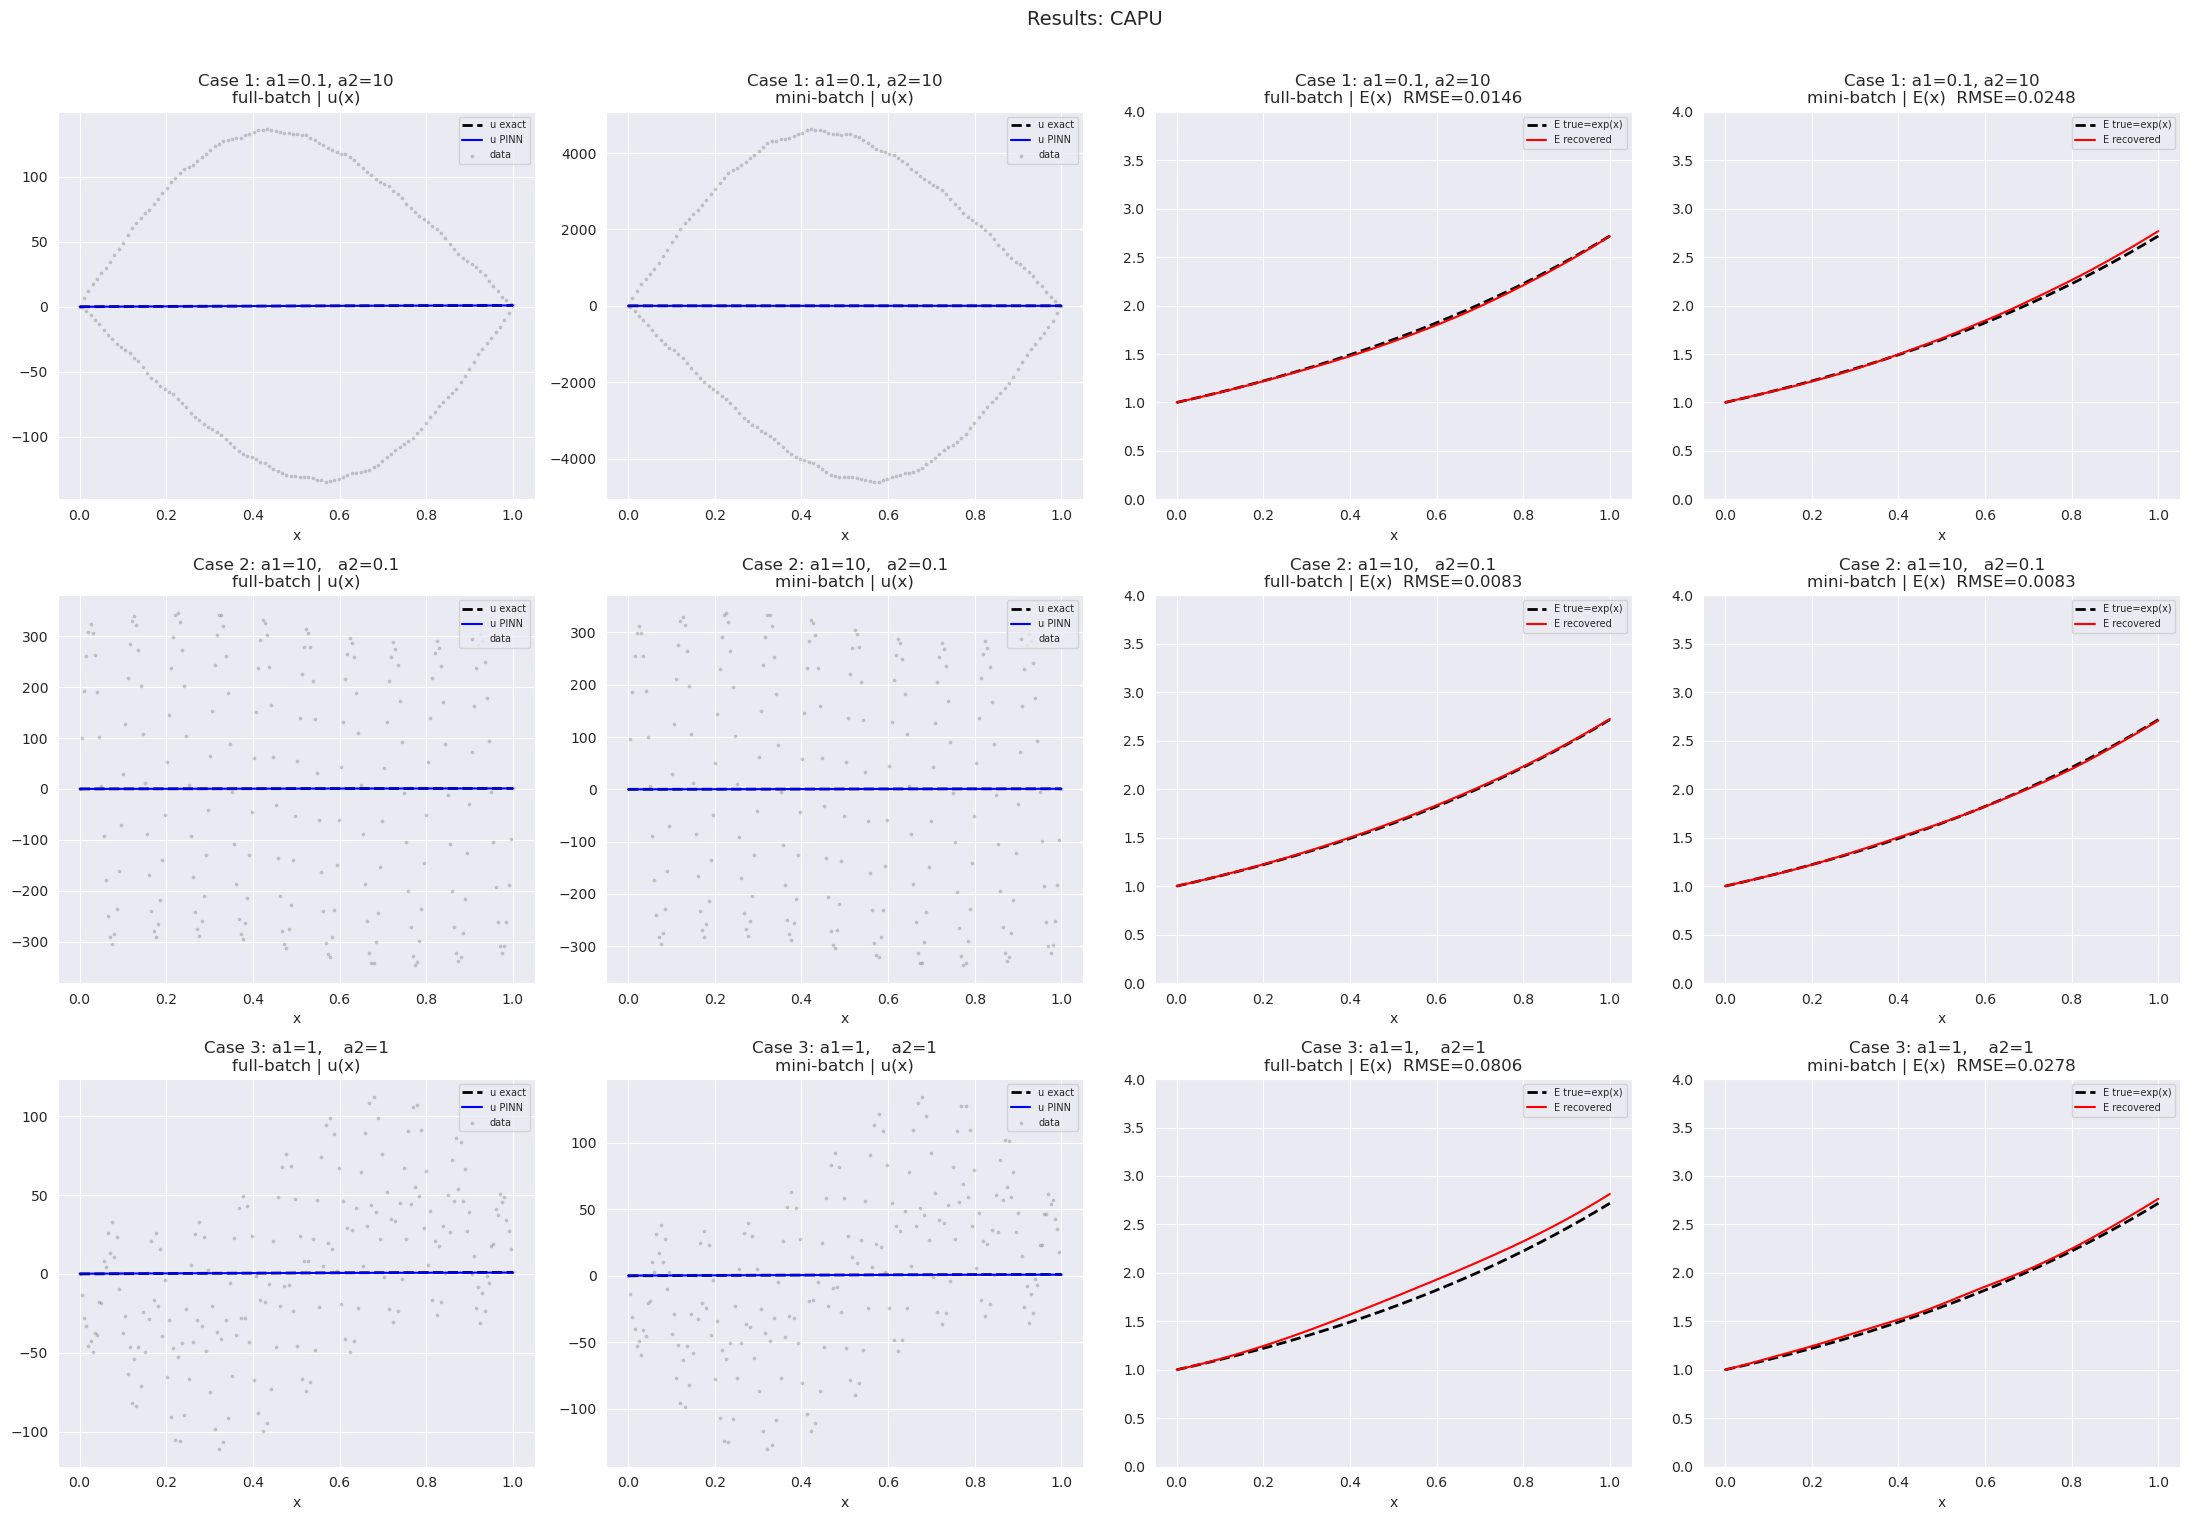

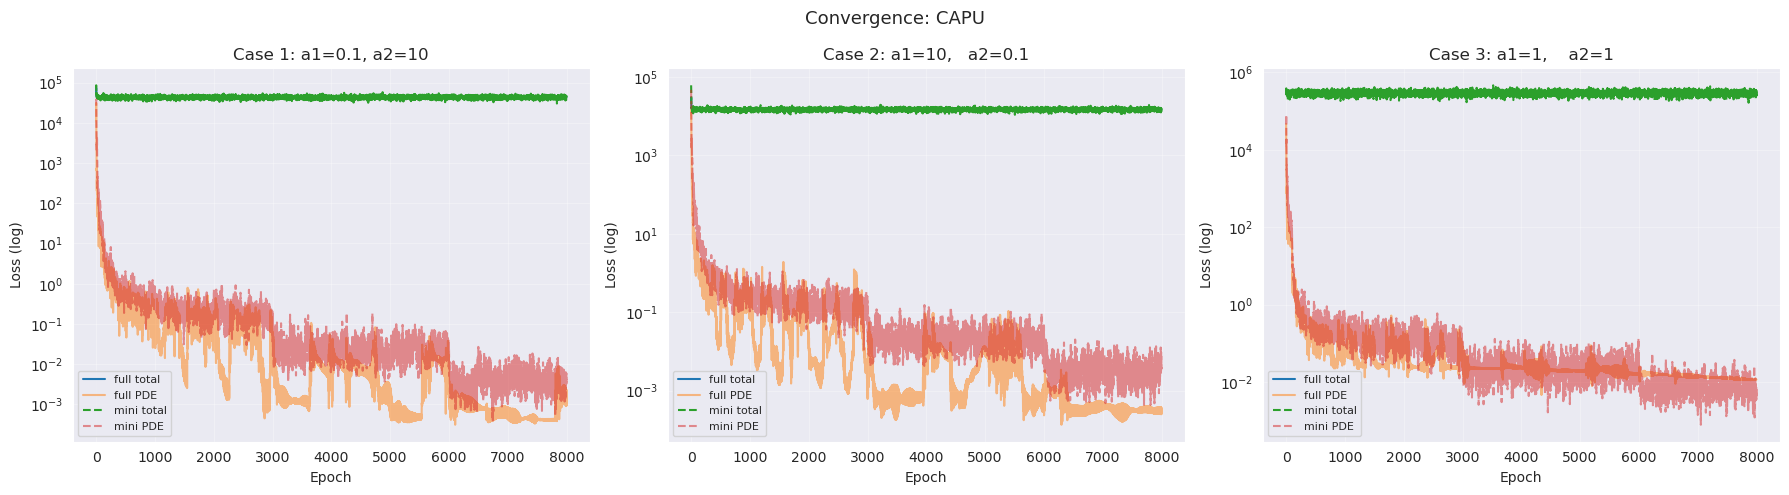

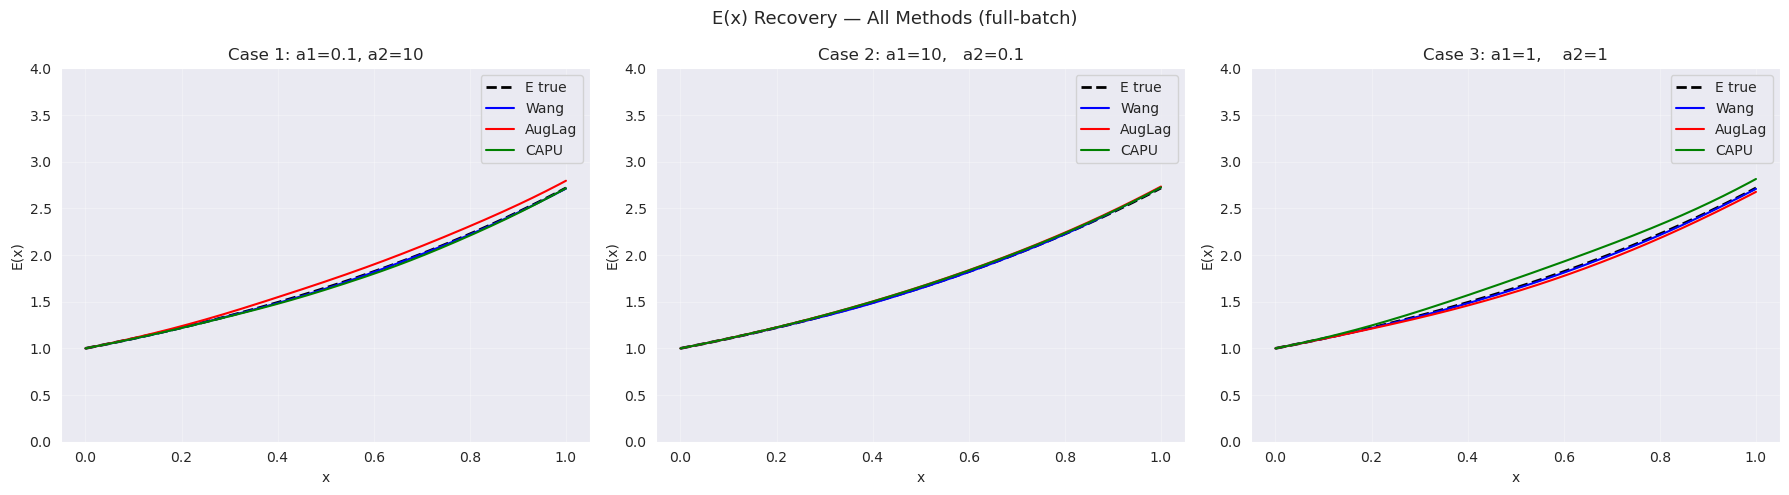

In [12]:
print("\n" + "="*60)
print("  PART (iii): CAPU")
print("="*60)
results_capu = {}
for a1, a2, title in cases:
    print(f"\n  {title}")
    x_np, u_np = generate_data(a1, a2, L=L, uL=u_L)
    for bmode in ['full', 'mini']:
        print(f"    batch={bmode}")
        net_u, hist = train_pinn(x_np, u_np, method='capu',
                                  batch_mode=bmode, n_epochs=8000,
                                  lr=1e-3, L=L, uL=u_L,
                                  freq_scale=10.0, print_every=4000)
        results_capu[(a1, a2, bmode)] = (net_u, hist)

plot_results(results_capu, "CAPU", cases)
plot_convergence(results_capu, "CAPU", cases)
compare_methods(cases, results_wang, results_auglag, results_capu)


  PART (iv): Domain size L = 1, 10, 100, 1000

  L = 1
  Epoch  2500 | Data 2.064e+03 | PDE 2.208e-01 | BC 2.265e-04 | λ 38.2751
  Epoch  5000 | Data 2.064e+03 | PDE 9.433e-03 | BC 3.690e-04 | λ 40.5728
  Epoch  2500 | Data 2.373e+03 | PDE 1.291e-01 | BC 1.844e-03 | λ 39.5152
  Epoch  5000 | Data 1.727e+03 | PDE 2.009e-03 | BC 3.980e-04 | λ 44.8526

  L = 10
  Epoch  2500 | Data 7.263e+02 | PDE 3.452e-04 | BC 4.237e-03 | λ 96.4299
  Epoch  5000 | Data 7.261e+02 | PDE 5.974e-04 | BC 9.142e-06 | λ 96.6815
  Epoch  2500 | Data 7.136e+02 | PDE 1.227e-02 | BC 1.142e-03 | λ 39.3790
  Epoch  5000 | Data 8.497e+02 | PDE 1.524e-03 | BC 9.975e-05 | λ 40.5945

  L = 100
  Epoch  2500 | Data nan | PDE nan | BC nan | λ 1.0000
  Epoch  5000 | Data nan | PDE nan | BC nan | λ 1.0000
  Epoch  2500 | Data nan | PDE nan | BC nan | λ 1.0000
  Epoch  5000 | Data nan | PDE nan | BC nan | λ 1.0000

  L = 1000
  Epoch  2500 | Data nan | PDE nan | BC nan | λ 1.0000
  Epoch  5000 | Data nan | PDE nan | BC nan 

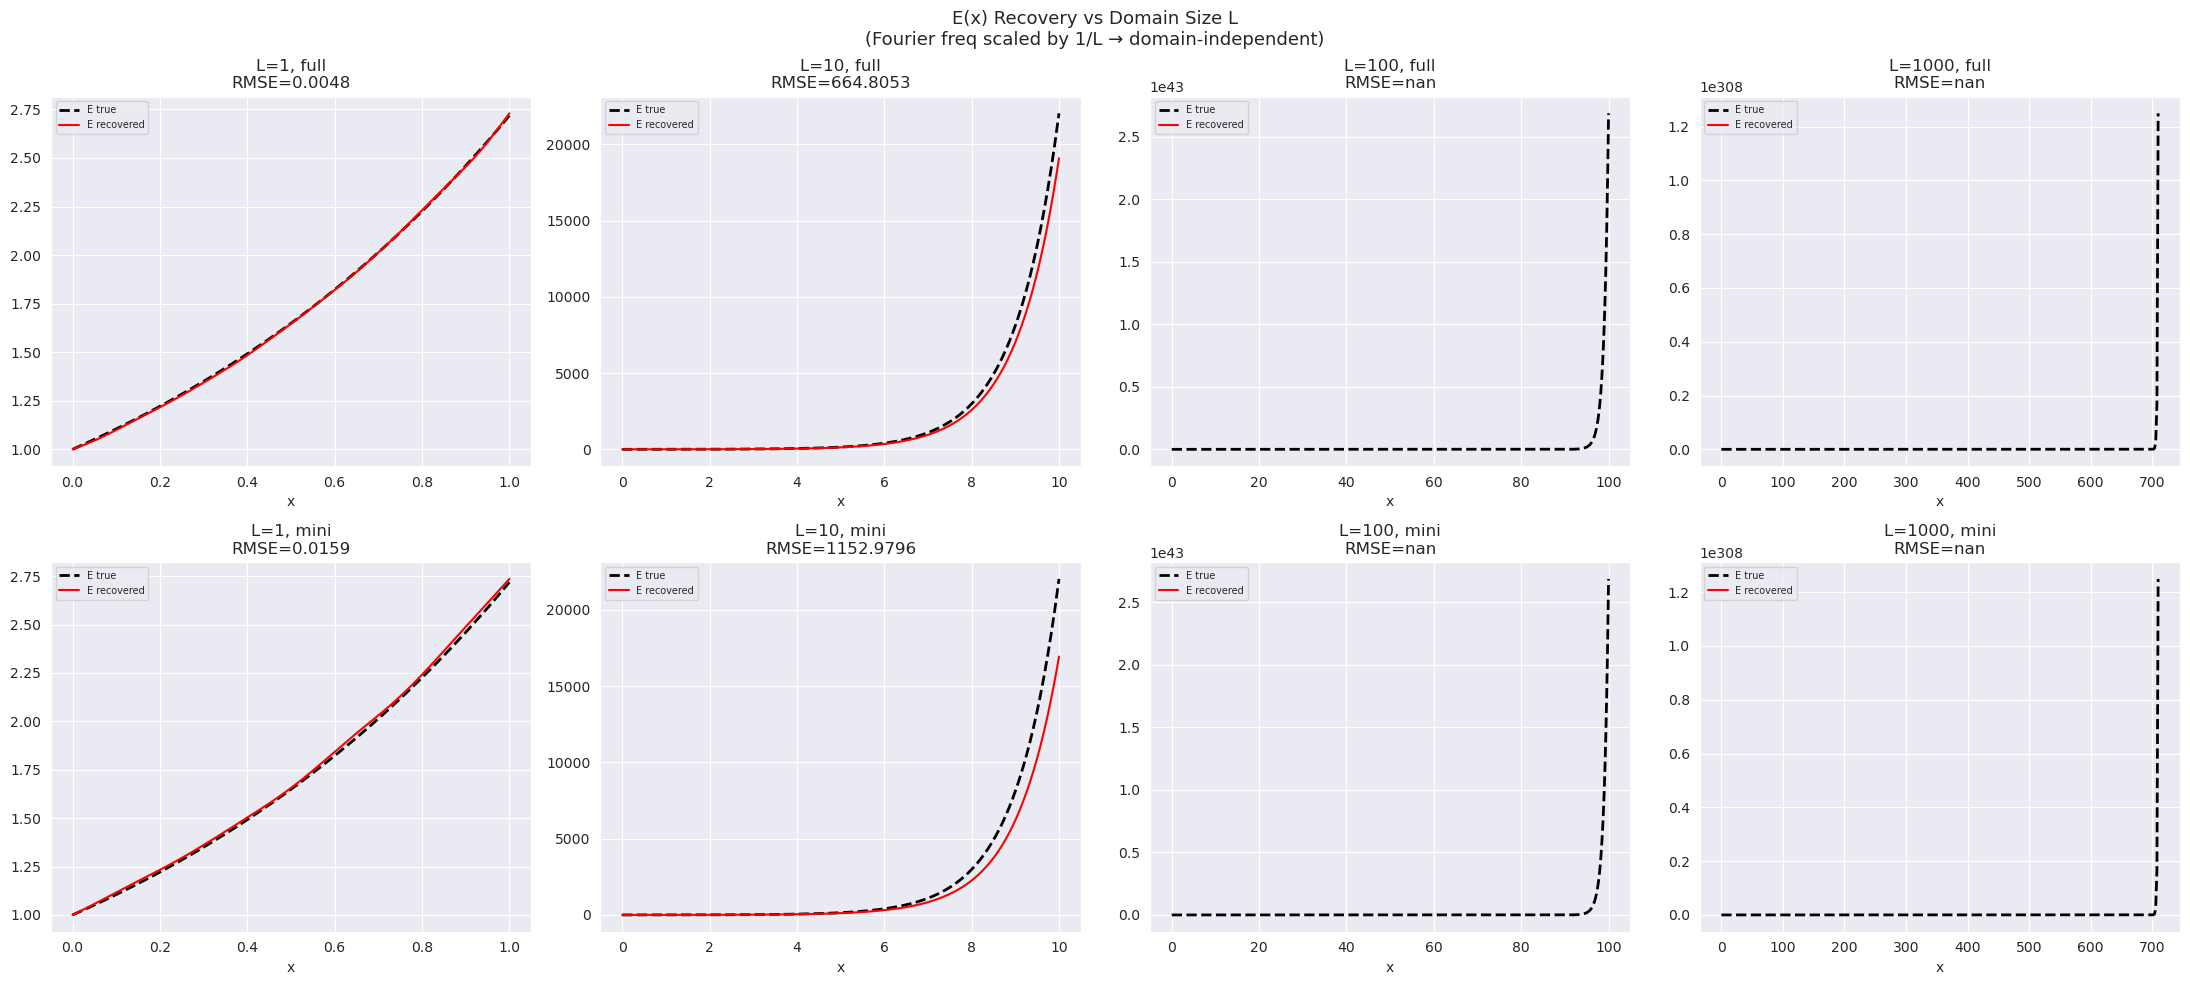

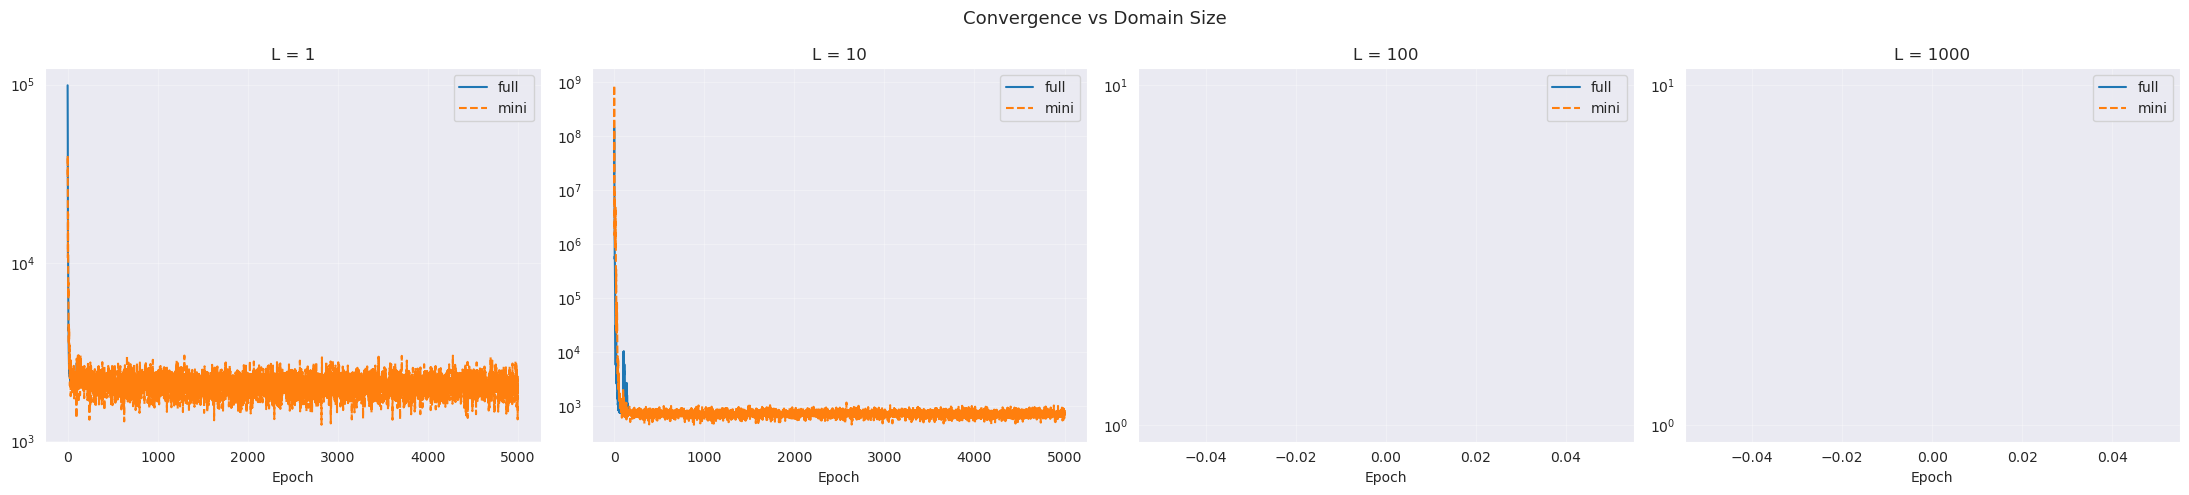

In [10]:
print("\n" + "="*60)
print("  PART (iv): Domain size L = 1, 10, 100, 1000")
print("="*60)
L_values  = [1, 10, 100, 1000]
results_L = {}

for Lv in L_values:
    print(f"\n  L = {Lv}")
    x_np, u_np = generate_data(1.0, 1.0, L=Lv, uL=u_L, N=N_data)

    for bmode in ['full', 'mini']:
        # freq_scale=10/Lv ensures network sees O(1) phase arguments
        net_u, hist = train_pinn(x_np, u_np, method='capu',
                                  batch_mode=bmode, n_epochs=5000,
                                  lr=1e-3, L=Lv, uL=u_L,
                                  freq_scale=10.0/Lv,
                                  print_every=2500)
        results_L[(Lv, bmode)] = (net_u, hist)

# Plot E(x) vs domain size
with sns.axes_style("darkgrid"):
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    for col, Lv in enumerate(L_values):
        x_plot_np = np.linspace(0, Lv, 500)
        x_plot_t  = torch.tensor(x_plot_np, dtype=torch.float32
                                ).unsqueeze(1).to(device)
        E_tr      = E_true(x_plot_np)
        for row, bmode in enumerate(['full', 'mini']):
            net_u, _ = results_L[(Lv, bmode)]
            net_u.eval()
            E_pred = recover_E(net_u, x_plot_t, L=Lv)
            rmse   = np.sqrt(np.mean((E_pred - E_tr)**2))
            ax     = axes[row, col]
            ax.plot(x_plot_np, E_tr,   'k--', lw=2,   label='E true')
            ax.plot(x_plot_np, E_pred, 'r-',  lw=1.5, label='E recovered')
            ax.set_title(f"L={Lv}, {bmode}\nRMSE={rmse:.4f}")
            ax.set_xlabel('x'); ax.legend(fontsize=7)
    plt.suptitle("E(x) Recovery vs Domain Size L\n"
                "(Fourier freq scaled by 1/L → domain-independent)", fontsize=13)
    plt.tight_layout(); plt.show()

with sns.axes_style("darkgrid"):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, Lv in zip(axes, L_values):
        for bmode, ls in [('full', '-'), ('mini', '--')]:
            hist = results_L[(Lv, bmode)][1]
            ax.semilogy(hist['total'], ls=ls, label=bmode)
        ax.set_title(f"L = {Lv}"); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle("Convergence vs Domain Size", fontsize=13)
    plt.tight_layout(); plt.show()

In [9]:
print("\n" + "="*70)
print("  FINAL SUMMARY — E(x) RMSE  (evaluated on L=1 domain)")
print("="*70)
x_ev  = np.linspace(0, 1.0, 500)
x_evt = torch.tensor(x_ev, dtype=torch.float32).unsqueeze(1).to(device)
E_ev  = E_true(x_ev)

print(f"\n{'Method':<20} {'Case':<25} {'Batch':<10} {'RMSE':>10}")
print("-"*70)
for mname, rdict in [('Wang',   results_wang),
                      ('AugLag', results_auglag),
                      ('CAPU',   results_capu)]:
    for a1, a2, title in cases:
        for bmode in ['full', 'mini']:
            net_u, _ = rdict[(a1, a2, bmode)]
            net_u.eval()
            E_pred = recover_E(net_u, x_evt)
            rmse   = np.sqrt(np.mean((E_pred - E_ev)**2))
            print(f"  {mname:<18} {title.split(':')[1].strip():<25} "
                  f"{bmode:<10} {rmse:>10.5f}")
print("="*70)


  FINAL SUMMARY — E(x) RMSE  (evaluated on L=1 domain)

Method               Case                      Batch            RMSE
----------------------------------------------------------------------
  Wang               a1=0.1, a2=10             full          0.00496
  Wang               a1=0.1, a2=10             mini          0.00681
  Wang               a1=10,   a2=0.1           full          0.00433
  Wang               a1=10,   a2=0.1           mini          0.01017
  Wang               a1=1,    a2=1             full          0.00864
  Wang               a1=1,    a2=1             mini          0.00357
  AugLag             a1=0.1, a2=10             full          0.06200
  AugLag             a1=0.1, a2=10             mini          0.09533
  AugLag             a1=10,   a2=0.1           full          0.01160
  AugLag             a1=10,   a2=0.1           mini          0.01022
  AugLag             a1=1,    a2=1             full          0.03510
  AugLag             a1=1,    a2=1          